In [57]:
import random
import torch  # Pytorch
from d2l import torch as d2l

先以线性模型参数 $\mathbf{w} = [2,-3.4]^T,b=4.2$ 和噪声项 $\varepsilon$ 生成数据集及标签：
$$
\mathbf{y} = \mathbf{Xw} + b + \varepsilon
$$

In [58]:
def synthetic_data(w, b, num_examples):  #@save
    """生成 y=Xw+b+噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)
print('features:', features[0],'\nlabel:', labels[0])

features: tensor([0.1522, 1.3707]) 
label: tensor([-0.1573])


先画出数据集在 $\R^2$ 中如何呈现。可以看到明显的线性关系。

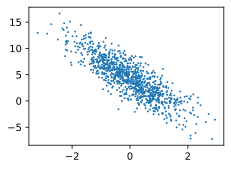

In [59]:
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);

从数据集中随机抽取小批量样本。

In [60]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [61]:
batch_size = 10
for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)

tensor([[ 0.1005, -0.9339],
        [ 0.2293, -0.8939],
        [ 0.4735, -1.3473],
        [ 0.0722, -0.1011],
        [ 0.3175, -0.6195],
        [-1.5385, -0.9649],
        [ 0.4830, -0.6456],
        [ 0.4872, -1.0654],
        [ 0.2109, -0.7832],
        [ 0.2217, -1.1000]]) 
 tensor([[7.5828],
        [7.7100],
        [9.7205],
        [4.6970],
        [6.9309],
        [4.4023],
        [7.3573],
        [8.7859],
        [7.2778],
        [8.3785]])
tensor([[ 1.0048, -0.0335],
        [-0.4578,  0.4919],
        [-0.1053, -2.1932],
        [ 0.6932, -0.2318],
        [ 0.2670,  0.7618],
        [-0.2904, -0.8998],
        [ 2.3865,  0.5384],
        [-2.4543, -0.7490],
        [-0.1698,  0.6995],
        [ 0.2466,  0.3929]]) 
 tensor([[ 6.3429],
        [ 1.6096],
        [11.4443],
        [ 6.3718],
        [ 2.1385],
        [ 6.6741],
        [ 7.1279],
        [ 1.8243],
        [ 1.4877],
        [ 3.3534]])
tensor([[-1.3694,  0.8766],
        [-1.4073,  0.9615],
      

初始化模型参数。从 $\mathcal{N}(0,0.01)$ 中采样随机数来初始化权重 $\mathbf{w}$，并将偏置初始化为 $0$。

In [62]:
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

定义模型。

In [63]:
def linear_reg(X, w, b):
    """线性回归模型"""
    return torch.matmul(X, w) + b

采用平方损失函数，后期对它计算梯度。

In [64]:
def squared_loss(y_hat, y):
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

小批量随机梯度下降 SGD

In [65]:
def SGD(params, learning_rate, batch_size):
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= learning_rate * param.grad / batch_size
            param.grad.zero_()

现在可以开始训练了。执行以下循环：
+ 初始化参数
+ 重复一下训练，直到完成：
    + 计算梯度 $\mathbf{g} \leftarrow \partial_{(\mathbf{w},b)}\dfrac{1}{|\mathcal{B}|}\sum_{i\in\mathcal{B}}l(\mathbf{x}^{(i)},y^{(i)},\mathcal{w},b)$
    + 更新参数 $(\mathbf{w},b)\leftarrow(\mathbf{w},b)-\eta\mathbf{g}$

在每个迭代周期（epoch）中，我们使用 `data_iter` 函数遍历整个数据集， 并将训练数据集中所有样本都使用一次（假设样本数能够被批量大小整除）。 这里的迭代周期个数 `num_epochs` 和学习率 `learning_rate` 都是超参数，分别设为 $3$ 和 $0.03$。

In [66]:
lr = 0.03
num_epochs = 3
net = linear_reg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)
        l.sum().backward()
        SGD([w, b], lr, batch_size)
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}: loss {float(train_l.mean()): f}')

epoch 1: loss  0.047956
epoch 2: loss  0.000224
epoch 3: loss  0.000052


因为我们使用的是自己合成的数据集，所以我们知道真正的参数是什么。因此，我们可以通过比较真实参数和通过训练学到的参数来评估训练的成功程度。事实上，真实参数和通过训练学到的参数确实非常接近。

In [71]:
print(f"真实的 w：{true_w}\n训练得到的 w：{w}，误差 {true_w - w.reshape(true_w.shape)}")
print(f"真实的 b：{true_b}\n训练得到的 b：{b}，误差 {true_b - b}")

真实的 w：tensor([ 2.0000, -3.4000])
训练得到的 w：tensor([[ 1.9996],
        [-3.3988]], requires_grad=True)，误差 tensor([ 0.0004, -0.0012], grad_fn=<SubBackward0>)
真实的 b：4.2
训练得到的 b：tensor([4.1998], requires_grad=True)，误差 tensor([0.0002], grad_fn=<RsubBackward1>)
